## Meal-wise and Center-wise Demand Analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [3]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
meal_info = pd.read_csv("../data/meal_info.csv")
center_info = pd.read_csv("../data/fulfilment_center_info.csv")

In [4]:
meal_orders = (
    train.groupby("meal_id")["num_orders"]
    .agg(["sum", "mean", "median", "count"])
    .sort_values("sum", ascending=False)
)

display(meal_orders.head(10))

,sum,mean,median,count
meal_id,,,,
2290,9770303,877.204435,635.0,11138
1885,8346246,752.456365,567.0,11092
1754,6818059,612.473859,406.0,11132
1993,6656856,598.853544,473.0,11116
1109,6367773,571.921412,431.0,11134
2707,5932792,533.380563,366.0,11123
1971,5728620,515.998919,283.0,11102
2826,5090103,460.351180,366.0,11057
1727,4735987,425.286189,297.0,11136


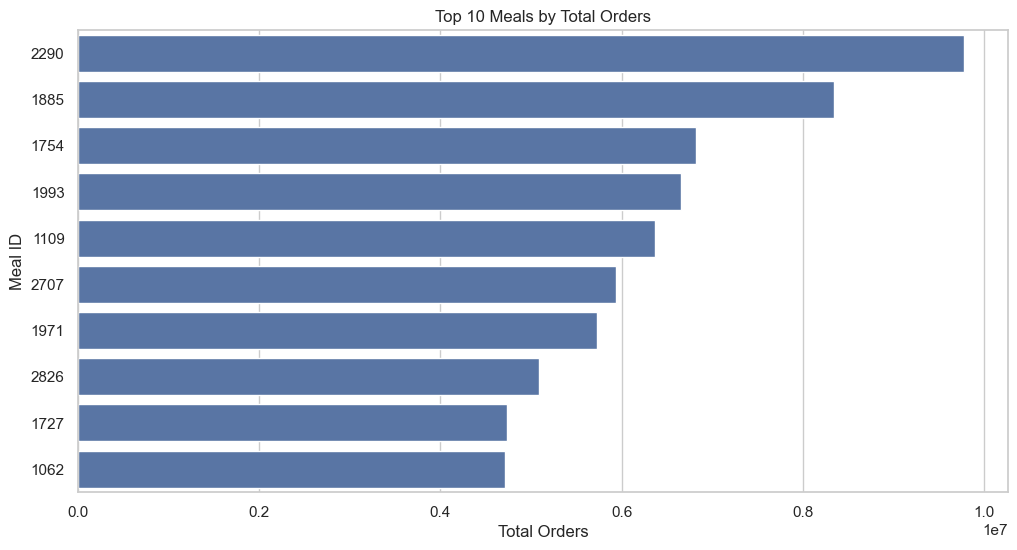

In [5]:
top_meals = (
    train.groupby("meal_id")["num_orders"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_meals.values,
    y=top_meals.index.astype(str)
)

plt.title("Top 10 Meals by Total Orders")
plt.xlabel("Total Orders")
plt.ylabel("Meal ID")
plt.show()

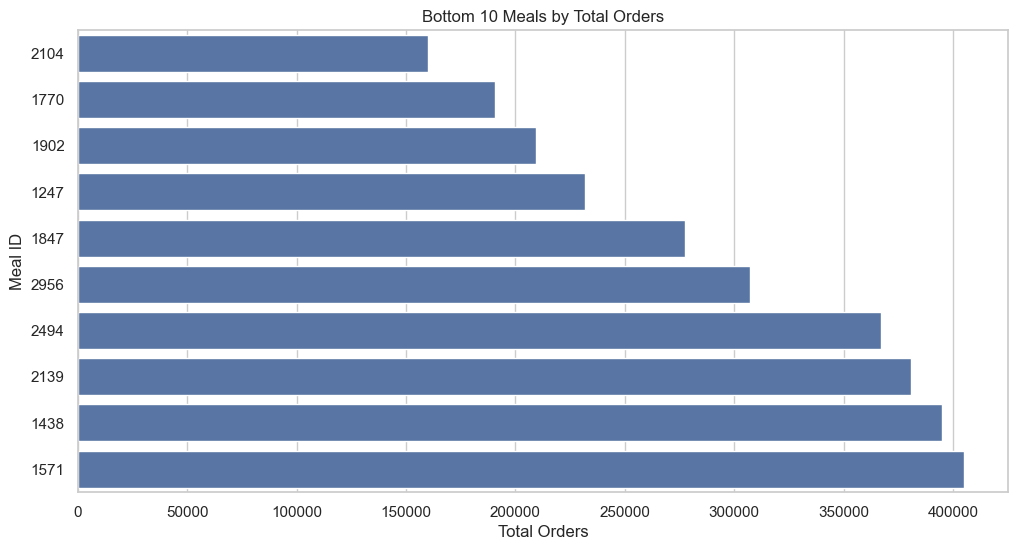

In [6]:
bottom_meals = (
    train.groupby("meal_id")["num_orders"]
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=bottom_meals.values,
    y=bottom_meals.index.astype(str)
)

plt.title("Bottom 10 Meals by Total Orders")
plt.xlabel("Total Orders")
plt.ylabel("Meal ID")
plt.show()

In [7]:
train_meal = train.merge(
    meal_info,
    on="meal_id",
    how="left"
)

train_meal.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian


In [8]:
category_orders = (
    train_meal.groupby("category")["num_orders"]
    .agg(["sum", "mean", "median", "count"])
    .sort_values("sum", ascending=False)
)

display(category_orders)

,sum,mean,median,count
category,,,,
Beverages,40480525,316.526116,189.0,127890
Rice Bowl,20874063,624.822288,433.0,33408
Sandwich,17636782,529.776276,351.0,33291
Salad,10944336,383.218460,298.0,28559
Pizza,7383720,222.817309,149.0,33138
Other Snacks,4766293,162.234691,109.0,29379
Starters,4649122,155.276110,109.0,29941
Extras,3984979,293.834169,217.0,13562
Seafood,2715714,100.895898,54.0,26916


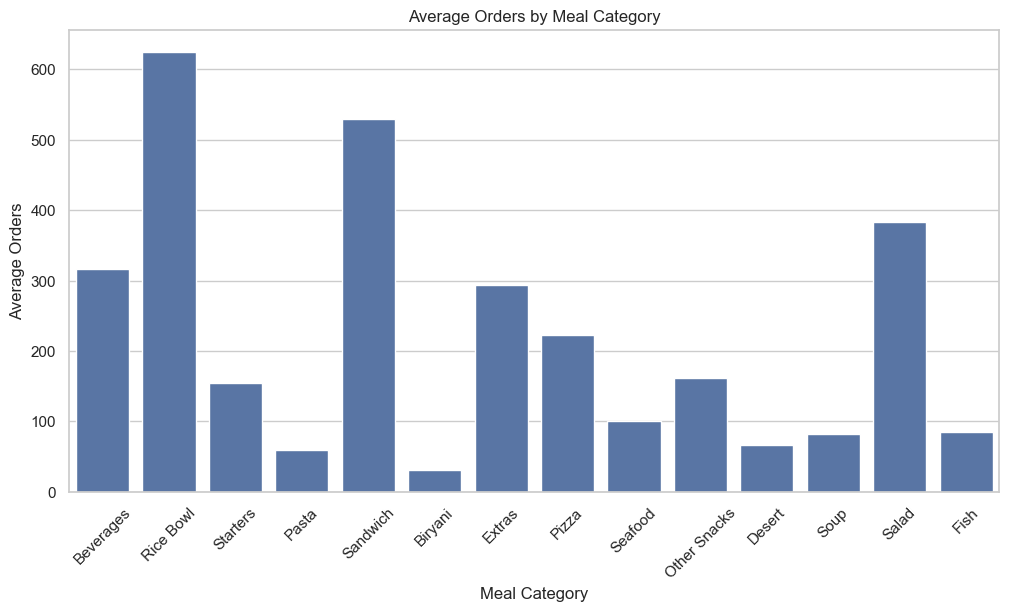

In [9]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=train_meal,
    x="category",
    y="num_orders",
    estimator="mean",
    errorbar=None
)

plt.title("Average Orders by Meal Category")
plt.xlabel("Meal Category")
plt.ylabel("Average Orders")
plt.xticks(rotation=45)
plt.show()

In [10]:
cuisine_orders = (
    train_meal.groupby("cuisine")["num_orders"]
    .agg(["sum", "mean", "median", "count"])
    .sort_values("sum", ascending=False)
)

display(cuisine_orders)

,sum,mean,median,count
cuisine,,,,
Italian,44172832,359.347830,256.0,122925
Thai,32677670,276.423411,161.0,118216
Indian,25792544,229.039037,68.0,112612
Continental,16914439,164.545348,108.0,102795


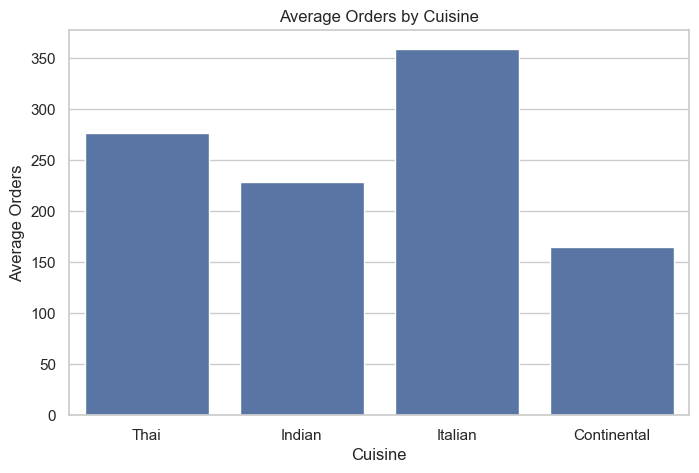

In [11]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=train_meal,
    x="cuisine",
    y="num_orders",
    estimator="mean",
    errorbar=None
)

plt.title("Average Orders by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Orders")
plt.show()

In [12]:
center_orders = (
    train.groupby("center_id")["num_orders"]
    .agg(["sum", "mean", "median", "count"])
    .sort_values("sum", ascending=False)
)

display(center_orders.head(10))

,sum,mean,median,count
center_id,,,,
13,4296545,609.784984,337.0,7046
43,3920294,562.452511,271.0,6970
10,3381018,481.969779,296.0,7015
52,3125835,446.994852,244.0,6993
137,3117478,452.201625,217.0,6894
67,2839493,410.628055,231.0,6915
11,2797300,411.307161,204.0,6801
174,2792587,405.251342,189.0,6891
104,2427542,363.024077,162.0,6687


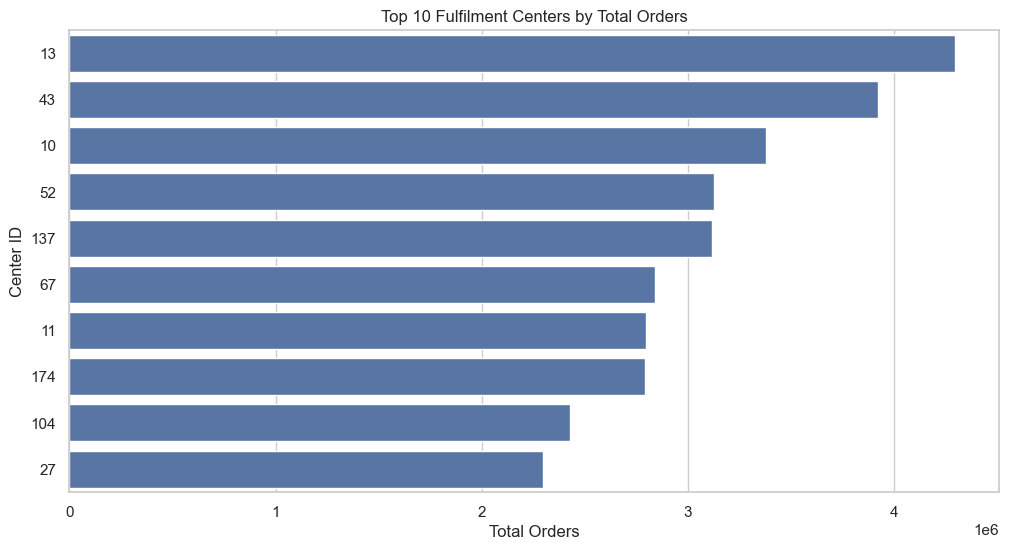

In [13]:
top_centers = (
    train.groupby("center_id")["num_orders"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_centers.values,
    y=top_centers.index.astype(str)
)

plt.title("Top 10 Fulfilment Centers by Total Orders")
plt.xlabel("Total Orders")
plt.ylabel("Center ID")
plt.show()

In [14]:
train_full = train.merge(
    meal_info,
    on="meal_id",
    how="left"
).merge(
    center_info,
    on="center_id",
    how="left"
)

train_full.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.0


In [16]:
center_type_orders = (
    train_full.groupby("center_type")["num_orders"]
    .agg(["sum", "mean", "median", "count"])
    .sort_values("sum", ascending=False)
)

display(center_type_orders)

,sum,mean,median,count
center_type,,,,
TYPE_A,68978517,262.394456,136.0,262881
TYPE_B,29996073,318.856145,176.0,94074
TYPE_C,20582895,206.670097,107.0,99593


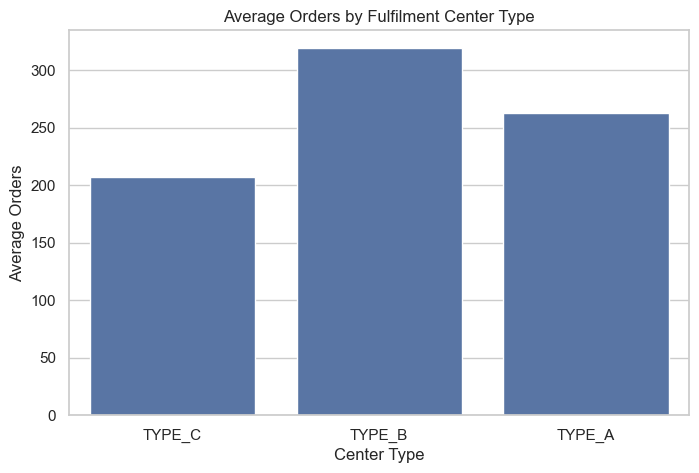

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=train_full,
    x="center_type",
    y="num_orders",
    estimator="mean",
    errorbar=None
)

plt.title("Average Orders by Fulfilment Center Type")
plt.xlabel("Center Type")
plt.ylabel("Average Orders")
plt.show()

In [17]:
city_orders = (
    train_full.groupby("city_code")["num_orders"]
    .agg(["sum", "mean", "median", "count"])
    .sort_values("sum", ascending=False)
)

display(city_orders.head(10))

,sum,mean,median,count
city_code,,,,
590,19849062,362.566434,163.0,54746
526,9207953,211.555497,122.0,43525
638,6662450,332.341497,162.0,20047
604,3533367,270.507350,122.0,13062
522,3375905,250.828813,134.0,13459
647,3268788,276.243387,123.0,11833
699,3221414,266.276575,121.0,12098
517,3205569,244.531925,148.0,13109
614,3166274,279.409989,161.0,11332


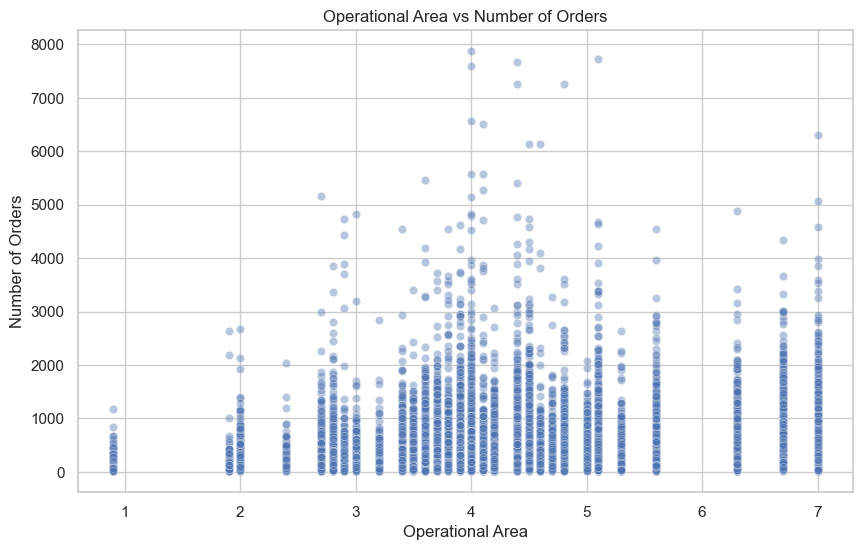

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train_full.sample(50000, random_state=42),
    x="op_area",
    y="num_orders",
    alpha=0.4
)

plt.title("Operational Area vs Number of Orders")
plt.xlabel("Operational Area")
plt.ylabel("Number of Orders")
plt.show()

## Price, Discount & Promotion Analysis

In [19]:
train_full["discount_amount"] = (
    train_full["base_price"] - train_full["checkout_price"]
)

train_full["discount_percentage"] = (
    (train_full["base_price"] - train_full["checkout_price"])
    / train_full["base_price"]
) * 100

train_full[[
    "checkout_price",
    "base_price",
    "discount_amount",
    "discount_percentage",
    "num_orders"
]].head()

,checkout_price,base_price,discount_amount,discount_percentage,num_orders
0,136.83,152.29,15.46,10.151684,177
1,136.83,135.83,-1.00,-0.736214,270
2,134.86,135.86,1.00,0.736052,189
3,339.50,437.53,98.03,22.405321,54
4,243.50,242.50,-1.00,-0.412371,40


In [20]:
print("Negative discount:", (train_full["discount_amount"] < 0).sum())
print("Zero discount:", (train_full["discount_amount"] == 0).sum())
print("Positive discount:", (train_full["discount_amount"] > 0).sum())

Negative discount: 116101
Zero discount: 110760
Positive discount: 229687


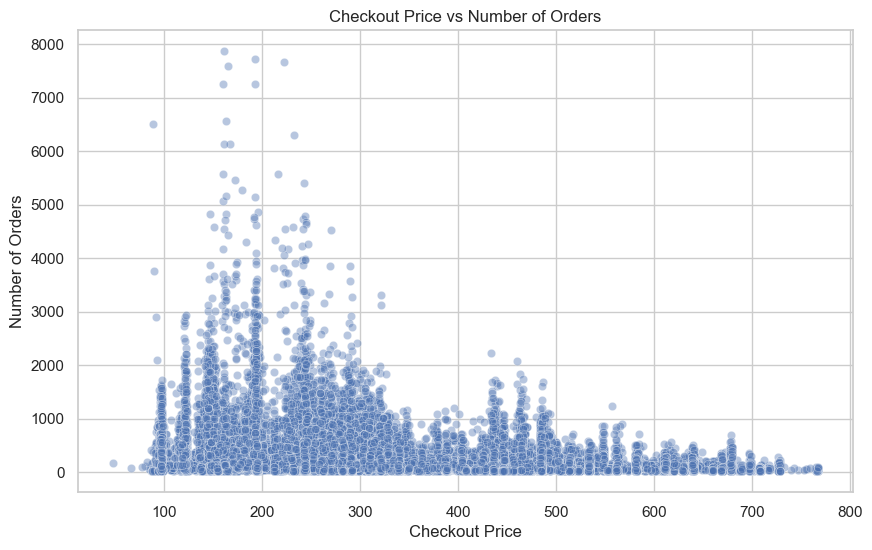

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train_full.sample(50000, random_state=42),
    x="checkout_price",
    y="num_orders",
    alpha=0.4
)

plt.title("Checkout Price vs Number of Orders")
plt.xlabel("Checkout Price")
plt.ylabel("Number of Orders")
plt.show()

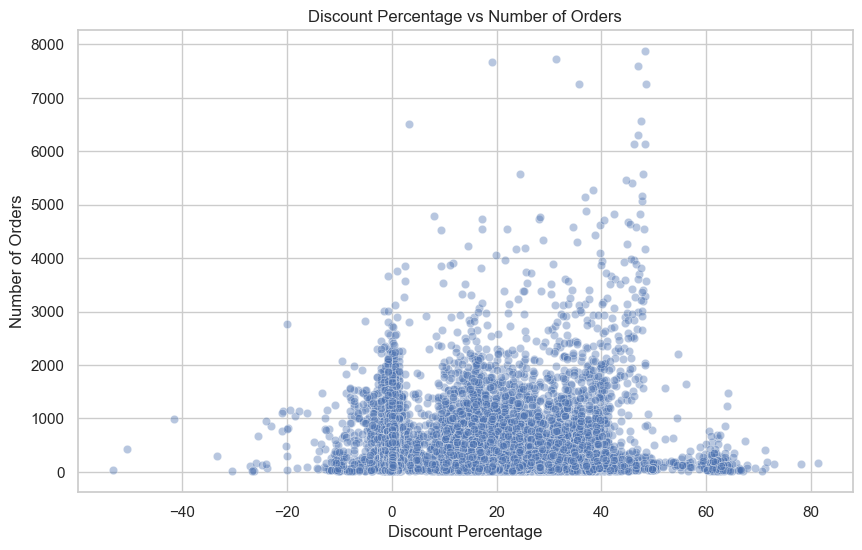

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train_full.sample(50000, random_state=42),
    x="discount_percentage",
    y="num_orders",
    alpha=0.4
)

plt.title("Discount Percentage vs Number of Orders")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Orders")
plt.show()

In [23]:
train_full[
    [
        "checkout_price",
        "base_price",
        "discount_amount",
        "discount_percentage",
        "num_orders"
    ]
].corr()["num_orders"].sort_values(ascending=False)

num_orders             1.000000
discount_percentage    0.205188
discount_amount        0.152950
base_price            -0.222306
checkout_price        -0.282108
Name: num_orders, dtype: float64

## Promotion analysis

In [24]:
email_promotion = (
    train_full
    .groupby("emailer_for_promotion")["num_orders"]
    .agg(["count", "sum", "mean", "median"])
)

display(email_promotion)

,count,sum,mean,median
emailer_for_promotion,,,,
0,419498,96175321,229.262883,123.0
1,37050,23382164,631.097544,338.0


In [25]:
homepage_featured = (
    train_full
    .groupby("homepage_featured")["num_orders"]
    .agg(["count", "sum", "mean", "median"])
)

display(homepage_featured)

,count,sum,mean,median
homepage_featured,,,,
0,406693,89899504,221.050040,123.0
1,49855,29657981,594.884786,350.0


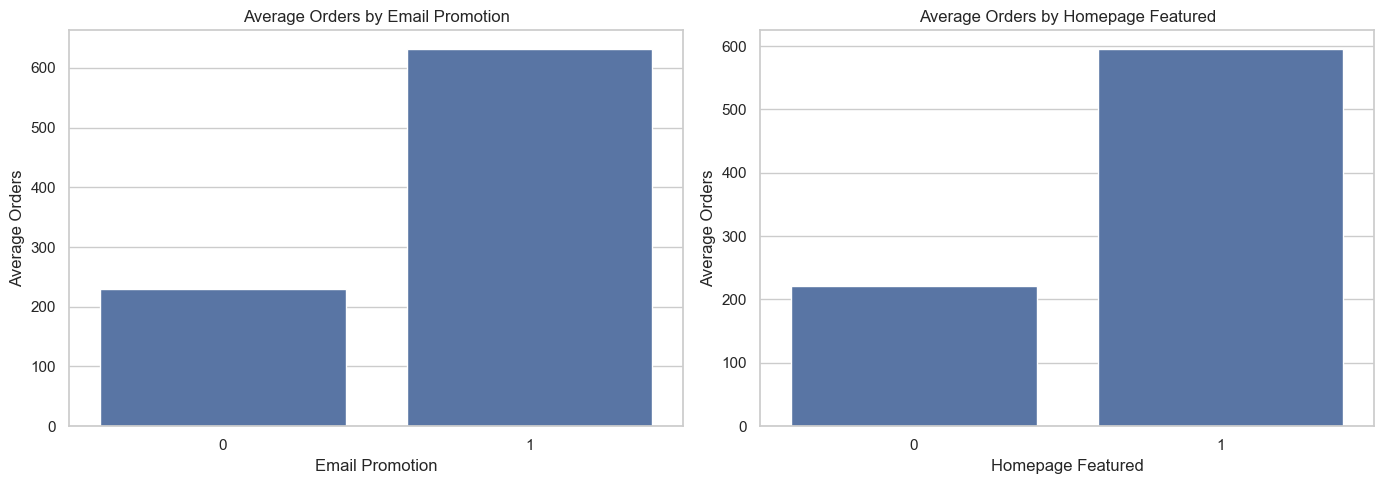

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=train_full,
    x="emailer_for_promotion",
    y="num_orders",
    estimator="mean",
    errorbar=None,
    ax=axes[0]
)

axes[0].set_title("Average Orders by Email Promotion")
axes[0].set_xlabel("Email Promotion")
axes[0].set_ylabel("Average Orders")

sns.barplot(
    data=train_full,
    x="homepage_featured",
    y="num_orders",
    estimator="mean",
    errorbar=None,
    ax=axes[1]
)

axes[1].set_title("Average Orders by Homepage Featured")
axes[1].set_xlabel("Homepage Featured")
axes[1].set_ylabel("Average Orders")

plt.tight_layout()
plt.show()

In [27]:
promotion_combination = (
    train_full
    .groupby(
        ["emailer_for_promotion", "homepage_featured"]
    )["num_orders"]
    .agg(["count", "mean", "median", "sum"])
    .reset_index()
)

display(promotion_combination)

,emailer_for_promotion,homepage_featured,count,mean,median,sum
0,0,0,388874,211.416983,122.0,82214568
1,0,1,30624,455.876208,258.0,13960753
2,1,0,17819,431.277625,229.0,7684936
3,1,1,19231,816.246061,474.0,15697228


In [28]:
series_counts = (
    train
    .groupby(["center_id", "meal_id"])["week"]
    .nunique()
)

print("Minimum weeks:", series_counts.min())
print("Maximum weeks:", series_counts.max())
print("Average weeks:", series_counts.mean())

Minimum weeks: 1
Maximum weeks: 145
Average weeks: 126.9246594384209


In [29]:
total_combinations = train[
    ["center_id", "meal_id"]
].drop_duplicates().shape[0]

print("Total center-meal combinations:", total_combinations)
print("Possible combinations:", 77 * 51)

Total center-meal combinations: 3597
Possible combinations: 3927


In [30]:
complete_series = (
    series_counts == train["week"].nunique()
).sum()

print("Complete 145-week series:", complete_series)
print("Incomplete series:", len(series_counts) - complete_series)

Complete 145-week series: 1247
Incomplete series: 2350


In [31]:
duplicate_series = (
    train
    .groupby(["center_id", "meal_id", "week"])
    .size()
)

print(
    "Duplicate center-meal-week combinations:",
    (duplicate_series > 1).sum()
)

Duplicate center-meal-week combinations: 0


In [32]:
weekly_records = (
    train.groupby("week")
    .size()
    .reset_index(name="records")
)

display(weekly_records.head(10))
display(weekly_records.tail(10))

,week,records
0,1,2922
1,2,2896
2,3,2899
3,4,2889
4,5,2859
5,6,2846
6,7,2795
7,8,2786
8,9,2854
9,10,2859


,week,records
135,136,3273
136,137,3283
137,138,3278
138,139,3279
139,140,3332
140,141,3263
141,142,3238
142,143,3305
143,144,3302
144,145,3268


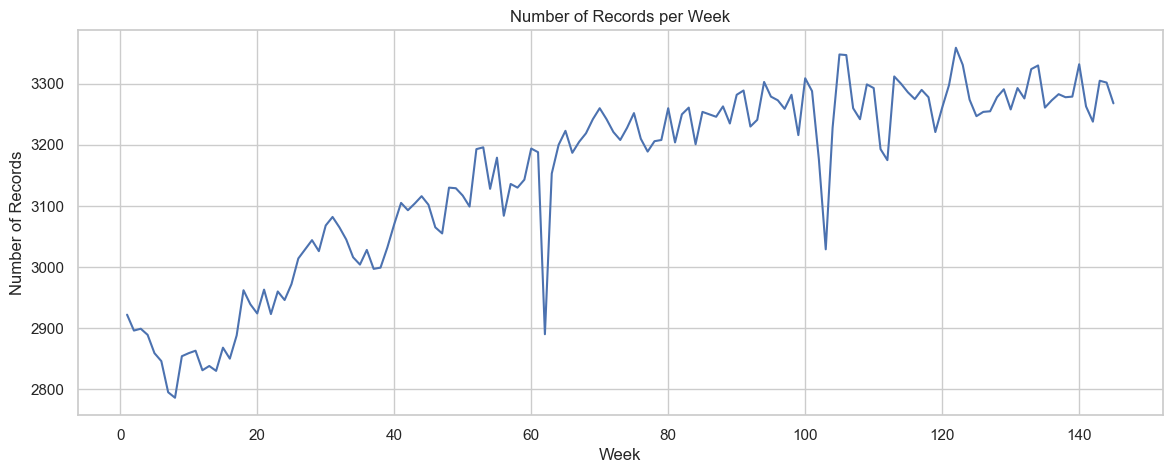

In [33]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=weekly_records,
    x="week",
    y="records"
)

plt.title("Number of Records per Week")
plt.xlabel("Week")
plt.ylabel("Number of Records")
plt.show()

## Time-Series Structure

In [34]:
all_weeks = set(train["week"].unique())

missing_week_info = []

for (center, meal), group in train.groupby(["center_id", "meal_id"]):
    existing_weeks = set(group["week"])
    missing_weeks = sorted(all_weeks - existing_weeks)

    missing_week_info.append({
        "center_id": center,
        "meal_id": meal,
        "observed_weeks": len(existing_weeks),
        "missing_weeks": len(missing_weeks),
        "first_week": group["week"].min(),
        "last_week": group["week"].max()
    })

missing_week_df = pd.DataFrame(missing_week_info)

display(missing_week_df.head())

,center_id,meal_id,observed_weeks,missing_weeks,first_week,last_week
0,10,1062,145,0,1,145
1,10,1109,145,0,1,145
2,10,1198,145,0,1,145
3,10,1207,144,1,1,145
4,10,1216,143,2,1,145


In [35]:
missing_week_df["missing_weeks"].describe()

count    3597.000000
mean       18.075341
std        28.807194
min         0.000000
25%         0.000000
50%         5.000000
75%        23.000000
max       144.000000
Name: missing_weeks, dtype: float64

In [36]:
bins = [0, 5, 20, 50, 100, 144, 145]
labels = [
    "0-5 missing",
    "6-20 missing",
    "21-50 missing",
    "51-100 missing",
    "101-144 missing",
    "145 missing"
]

missing_week_df["missing_group"] = pd.cut(
    missing_week_df["missing_weeks"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

display(
    missing_week_df["missing_group"]
    .value_counts()
    .sort_index()
)

missing_group
0-5 missing        1875
6-20 missing        732
21-50 missing       537
51-100 missing      334
101-144 missing     119
145 missing           0
Name: count, dtype: int64

In [37]:
missing_pattern = []

for (center, meal), group in train.groupby(["center_id", "meal_id"]):

    weeks = sorted(group["week"].unique())

    missing_before = weeks[0] - 1
    missing_after = 145 - weeks[-1]

    expected = set(range(weeks[0], weeks[-1] + 1))
    missing_inside = len(expected - set(weeks))

    missing_pattern.append({
        "center_id": center,
        "meal_id": meal,
        "missing_before": missing_before,
        "missing_inside": missing_inside,
        "missing_after": missing_after
    })

missing_pattern = pd.DataFrame(missing_pattern)

display(missing_pattern.head())

,center_id,meal_id,missing_before,missing_inside,missing_after
0,10,1062,0,0,0
1,10,1109,0,0,0
2,10,1198,0,0,0
3,10,1207,0,1,0
4,10,1216,0,2,0


In [38]:
print(
    "Series with internal missing weeks:",
    (missing_pattern["missing_inside"] > 0).sum()
)

print(
    "Series with missing weeks only at beginning/end:",
    (missing_pattern["missing_inside"] == 0).sum()
)

Series with internal missing weeks: 2129
Series with missing weeks only at beginning/end: 1468


## Temporal Demand Patterns

In [39]:
weekly_orders["pct_change"] = (
    weekly_orders["num_orders"]
    .pct_change() * 100
)

display(weekly_orders.head(15))

NameError: name 'weekly_orders' is not defined

In [ ]:
print("Largest increases:")
display(
    weekly_orders
    .sort_values("pct_change", ascending=False)
    .head(10)
)

print("Largest decreases:")
display(
    weekly_orders
    .sort_values("pct_change")
    .head(10)
)

In [40]:
train_full["period"] = pd.cut(
    train_full["week"],
    bins=[0, 30, 60, 90, 120, 145],
    labels=[
        "Weeks 1-30",
        "Weeks 31-60",
        "Weeks 61-90",
        "Weeks 91-120",
        "Weeks 121-145"
    ]
)

period_orders = (
    train_full
    .groupby("period", observed=True)["num_orders"]
    .agg(["sum", "mean", "median"])
)

display(period_orders)

,sum,mean,median
period,,,
Weeks 1-30,22987978,263.191990,136.0
Weeks 31-60,25813911,278.059277,149.0
Weeks 61-90,24787062,257.028547,134.0
Weeks 91-120,25502584,260.810620,136.0
Weeks 121-145,20465950,249.129032,135.0


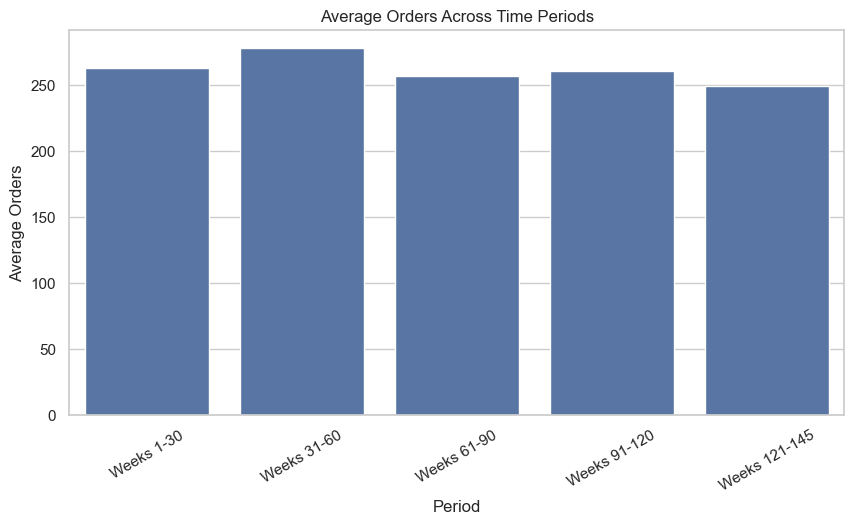

In [41]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=train_full,
    x="period",
    y="num_orders",
    estimator="mean",
    errorbar=None
)

plt.title("Average Orders Across Time Periods")
plt.xlabel("Period")
plt.ylabel("Average Orders")
plt.xticks(rotation=30)
plt.show()

## Seasonality / Autocorrelation

In [51]:

weekly_orders = (
    train.groupby("week")["num_orders"]
    .sum()
    .reset_index()
)

weekly_orders.head()

,week,num_orders
0,1,792261
1,2,787084
2,3,695262
3,4,743529
4,5,1198675


In [54]:
weekly_orders["rolling_mean_10"] = (
    weekly_orders["num_orders"]
    .rolling(window=10)
    .mean()
)

In [53]:
%pip install statsmodels


  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.4 MB 8.5 MB/s eta 0:00:02
   --------------------------- ------------ 7.9/11.4 MB 28.7 MB/s eta 0:00:01
   ---------------------------------------- 11.4/11.4 MB 28.5 MB/s  0:00:00
Using cached narwhals-2.25.0-py3-none-any.whl (467 kB)

   ---------------------------------------- 0/6 [wrapt]
   ------ --------------------------------- 1/6 [patsy]
   ------ --------------------------------- 1/6 [patsy]
   ------ --------------------------------- 1/6 [patsy]
   ------ --------------------------------- 1/6 [patsy]
   ------------- -------------------------- 2/6 [narwhals]
   ------------- -------------------------- 2/6 [narwhals]
   ------------- -------------------------- 2/6 [narwhals]
   ------------- -------------------------- 2/6 [narwhals]
   ------------- -------------------------- 2/6 [narwhals]
  

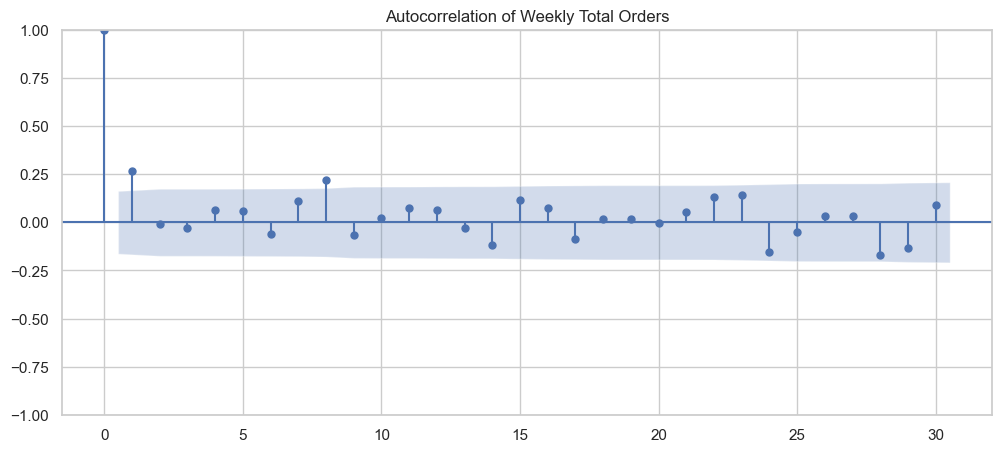

In [55]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))

plot_acf(
    weekly_orders["num_orders"],
    lags=30,
    ax=plt.gca()
)

plt.title("Autocorrelation of Weekly Total Orders")
plt.show()

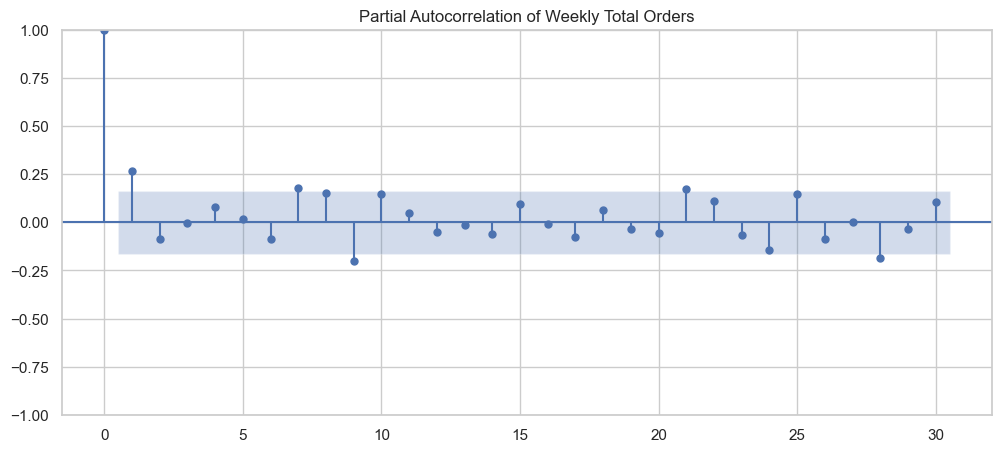

In [57]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plot_pacf(
    weekly_orders["num_orders"],
    lags=30,
    ax=plt.gca(),
    method="ywm"
)

plt.title("Partial Autocorrelation of Weekly Total Orders")
plt.show()

In [43]:
complete_series = (
    missing_week_df[
        missing_week_df["missing_weeks"] == 0
    ][["center_id", "meal_id"]]
)

complete_series.head()

,center_id,meal_id
0,10,1062
1,10,1109
2,10,1198
5,10,1230
7,10,1248


In [44]:
sample_center = complete_series.iloc[0]["center_id"]
sample_meal = complete_series.iloc[0]["meal_id"]

sample_ts = (
    train[
        (train["center_id"] == sample_center) &
        (train["meal_id"] == sample_meal)
    ]
    .sort_values("week")
)

print("Center:", sample_center)
print("Meal:", sample_meal)
print("Observations:", len(sample_ts))

Center: 10
Meal: 1062
Observations: 145


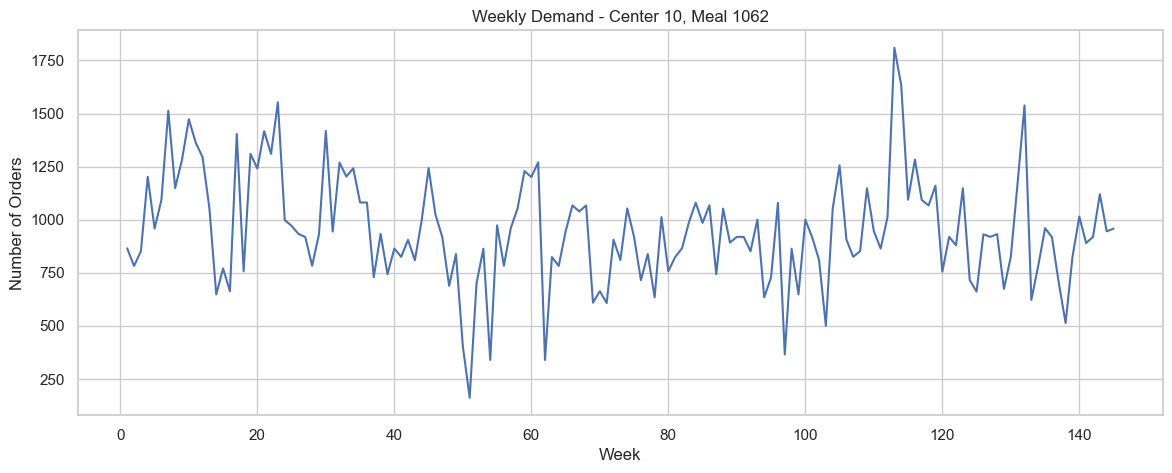

In [45]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=sample_ts,
    x="week",
    y="num_orders"
)

plt.title(
    f"Weekly Demand - Center {int(sample_center)}, "
    f"Meal {int(sample_meal)}"
)

plt.xlabel("Week")
plt.ylabel("Number of Orders")
plt.show()

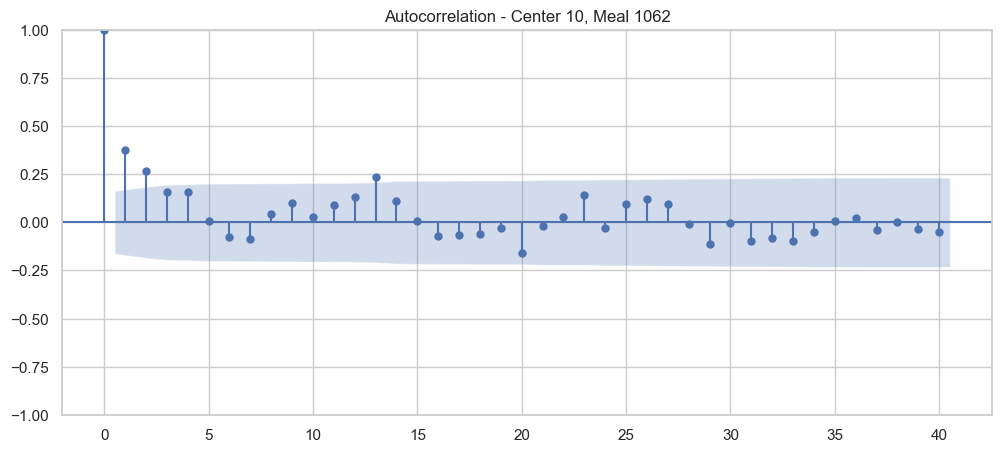

In [56]:
plt.figure(figsize=(12, 5))

plot_acf(
    sample_ts["num_orders"],
    lags=40,
    ax=plt.gca()
)

plt.title(
    f"Autocorrelation - Center {int(sample_center)}, "
    f"Meal {int(sample_meal)}"
)

plt.show()

## Final Feature Relationships

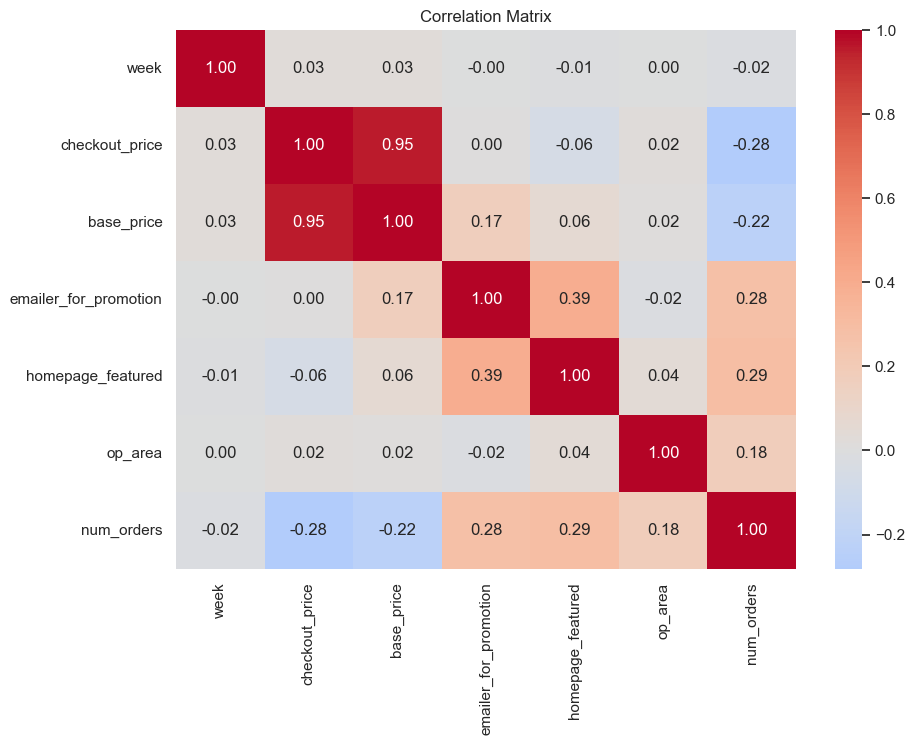

In [47]:
numeric_cols = [
    "week",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "op_area",
    "num_orders"
]

corr_matrix = train_full[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [48]:
display(
    train_full
    .groupby(["center_type", "cuisine"])["num_orders"]
    .mean()
    .unstack()
)

cuisine,Continental,Indian,Italian,Thai
center_type,,,,
TYPE_A,166.753082,223.373218,356.677765,286.208664
TYPE_B,164.424242,295.159725,408.221825,389.112587
TYPE_C,158.704509,179.790495,324.836322,135.510434


In [49]:
display(
    train_full
    .groupby(["category", "cuisine"])["num_orders"]
    .mean()
    .unstack()
)

cuisine,Continental,Indian,Italian,Thai
category,,,,
Beverages,182.559624,80.075061,418.021329,558.425855
Biryani,NaN,30.651402,NaN,NaN
Desert,NaN,66.250905,NaN,NaN
Extras,NaN,NaN,NaN,293.834169
Fish,85.595268,NaN,NaN,NaN
Other Snacks,NaN,NaN,NaN,162.234691
Pasta,NaN,NaN,59.137142,NaN
Pizza,222.817309,NaN,NaN,NaN
Rice Bowl,NaN,624.822288,NaN,NaN


In [62]:
train_full.to_csv("cleaned_food_delivery.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Shape:", train_full.shape)

Cleaned dataset saved successfully!
Shape: (456548, 18)
